In [141]:
from pathlib import Path
from parameters import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [143]:
def percentDiff(x1,x2):
    return (x1 - x2)/abs(x1) * 100

# Random Sweeps

In [133]:
simulation_results = pd.read_csv(str(Path(RESULTS_DIR) / "validation/random_candidates_em_sim_results.csv"))
ML_results = pd.read_csv(str(Path(RESULTS_DIR) / "validation/random_candidates_for_em_sim_validation.csv"))

In [134]:
pred_surr_pd_frequency = {"1":[],"2":[],"5":[],"10":[],"20":[],"40":[]}
pred_tar_pd_frequency = {"1":[],"2":[],"5":[],"10":[],"20":[],"40":[]}
pred_surr_pd_alpha = {"1":[],"2":[],"5":[],"10":[],"20":[],"40":[]}
pred_tar_pd_alpha = {"1":[],"2":[],"5":[],"10":[],"20":[],"40":[]}

for i in range(len(simulation_results)):

    current_design = ML_results.iloc[i]

    claw = current_design["design_options.connection_pads.readout.claw_length"]
    ground = current_design["design_options.connection_pads.readout.ground_spacing"]
    cross = current_design["design_options.cross_length"]

    current = simulation_results.iloc[i]
    current_sigma = int(current.sigma_for_gauss)
    pred_H_params = current.pred_H_params
    surrogate_H_params = current.surrogate_H_params
    target_H_params = current.target_H_params

    pd_pred_surr_frequency = percentDiff(eval(surrogate_H_params)["qubit_frequency_GHz"],eval(pred_H_params)["qubit_frequency_GHz"])
    pd_pred_tar_frequency = percentDiff(eval(target_H_params)["qubit_frequency_GHz"],eval(pred_H_params)["qubit_frequency_GHz"])
    pd_pred_surr_alpha = percentDiff(eval(surrogate_H_params)["anharmonicity_MHz"],eval(pred_H_params)["anharmonicity_MHz"])
    pd_pred_tar_alpha = percentDiff(eval(target_H_params)["anharmonicity_MHz"],eval(pred_H_params)["anharmonicity_MHz"])

    pred_surr_pd_frequency[str(current_sigma)] += [pd_pred_surr_frequency]
    pred_surr_pd_alpha[str(current_sigma)] += [pd_pred_surr_alpha]
    pred_tar_pd_frequency[str(current_sigma)] += [pd_pred_tar_frequency]
    pred_tar_pd_alpha[str(current_sigma)] += [pd_pred_tar_alpha]

In [148]:
for key in pred_surr_pd_frequency:
    current = pred_surr_pd_frequency[key]

In [149]:
pred_surr_pd_frequency

{'1': [0.027449265546669457,
  0.01901706046383501,
  1.8664764682463573,
  0.18463691221603662,
  0.19435588973386483,
  1.8523897281889805,
  0.16527684049815614,
  1.7069352103349942,
  0.42679123298000393,
  1.469810307777578,
  1.7961886893429289,
  0.13634098822778443,
  1.7982132809929854,
  1.8824086252258712,
  1.8024285977557368],
 '2': [0.08924065467421537,
  1.912432607278557,
  1.5600051806354338,
  0.06056837055451748,
  0.1327743798500393,
  1.409382531725883,
  1.6304169766415708,
  1.525915749457302,
  0.09039498735030471,
  0.11688077839286573,
  1.640389917011378,
  1.760946869353722,
  0.3401854675665825,
  0.05437950677260944,
  1.9556697074530602],
 '5': [2.038951287670729,
  0.43906357251552697,
  1.3155347395469328,
  1.3406574350658513,
  1.8356865735659298,
  1.536724355621977,
  2.292776822296578,
  0.3523742484688495,
  1.6350390958816277,
  1.7914810467749807,
  1.4672139843370036,
  1.2909270475446848,
  1.853007914861492,
  1.8155965765734865,
  1.7443551

# percent differences between target/surrogate and prediction vs $\sigma_{\text{noise}}$

## $f_q$ percent differences (EM simulator vs Surrogate & EM simulator vs Target)

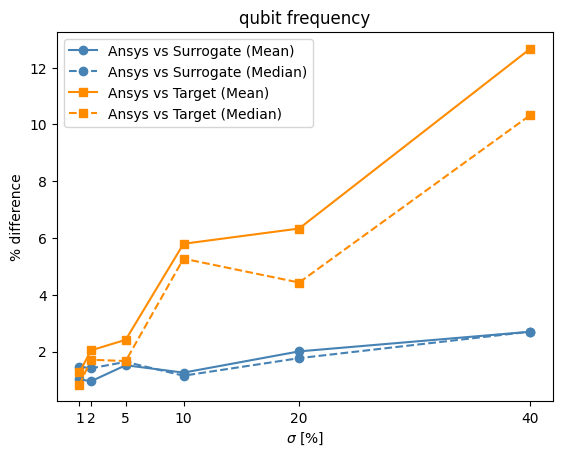

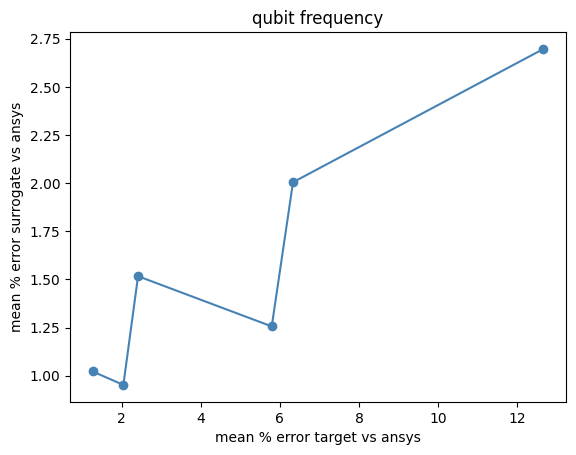

In [136]:
x = []
surrogate_means_f = []
surrogate_medians_f = []
target_means_f = []
target_medians_f = []

for key in list(pred_surr_pd_frequency.keys()):
    current_pred_surr_pd_frequency = pred_surr_pd_frequency[key]
    current_pred_tar_pd_frequency = pred_tar_pd_frequency[key]
    x.append(int(key))
    surrogate_means_f.append(np.mean(current_pred_surr_pd_frequency))
    target_means_f.append(np.mean(current_pred_tar_pd_frequency))
    surrogate_medians_f.append(np.median(current_pred_surr_pd_frequency))
    target_medians_f.append(np.median(current_pred_tar_pd_frequency))
    
plt.plot(x,surrogate_means_f,color = "steelblue",marker = "o",label = "EM simulator vs Surrogate (Mean)")
plt.plot(x,surrogate_medians_f,color = "steelblue",marker = "o",linestyle = "dashed",label = "EM simulator vs Surrogate (Median)")
plt.plot(x,target_means_f,color = "darkorange",marker = "s",label = "EM simulator vs Target (Mean)")
plt.plot(x,target_medians_f,color = "darkorange",marker = "s",linestyle = "dashed",label = "EM simulator vs Target (Median)")
plt.xticks(x,x)
plt.title("qubit frequency")
plt.legend()
plt.ylabel("% difference")
plt.xlabel(r"$\sigma$ [%]")
plt.show()

plt.plot(target_means_f,surrogate_means_f,color = "steelblue",marker = "o",label = "EM simulator vs Surrogate (Mean)")
plt.ylabel(r"mean % error surrogate vs EM simulator")
plt.xlabel(r"mean % error target vs EM simulator")
plt.title("qubit frequency")
plt.show()

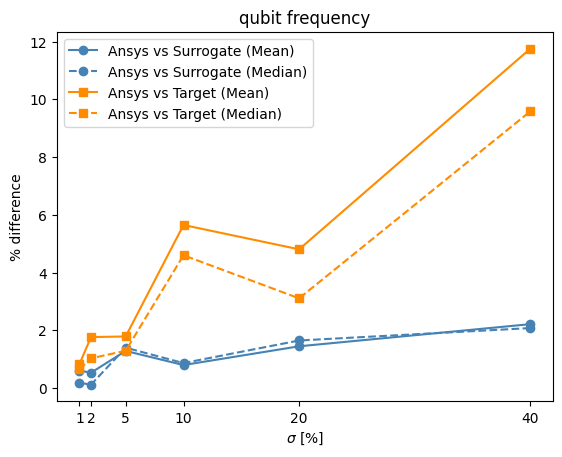

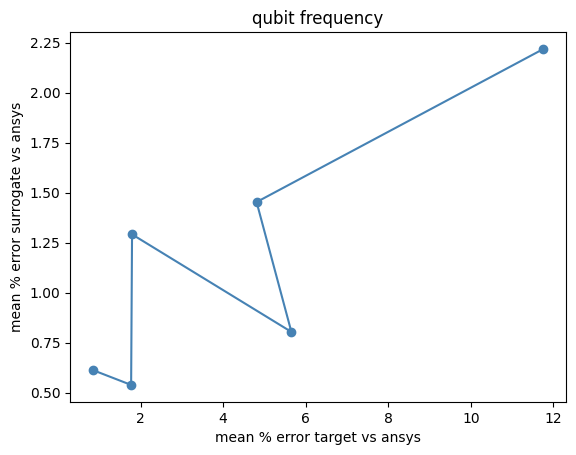

In [151]:

## indices of 10 smallest values
    
## apply same indices to both

## $\alpha$ percent differences (EM simulator vs Surrogate & EM simulator vs Target)

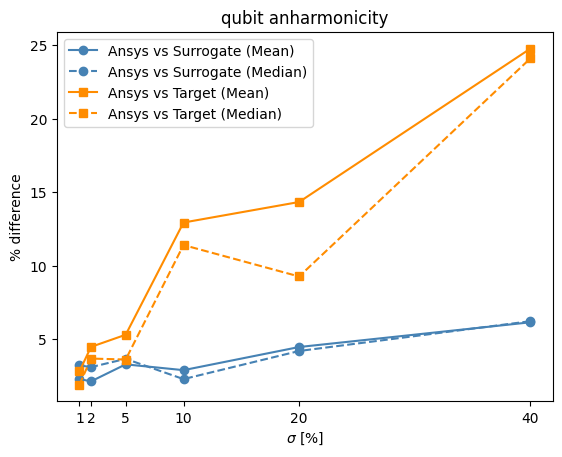

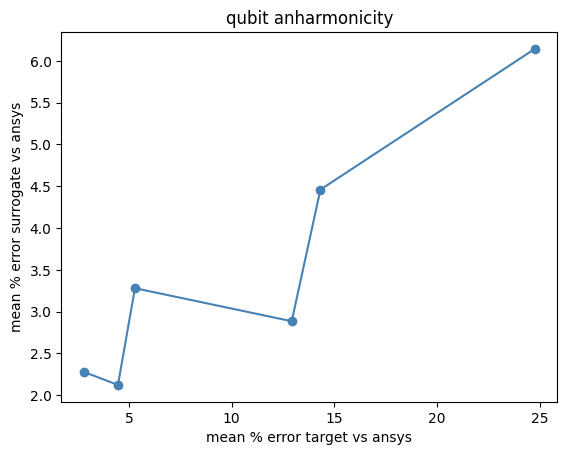

In [137]:
surrogate_means_alpha = []
surrogate_medians_alpha = []
target_means_alpha = []
target_medians_alpha = []
for key in list(pred_surr_pd_frequency.keys()):
    current_pred_surr_pd_alpha = pred_surr_pd_alpha[key]
    current_pred_tar_pd_alpha = pred_tar_pd_alpha[key]
    surrogate_means_alpha.append(np.mean(current_pred_surr_pd_alpha))
    target_means_alpha.append(np.mean(current_pred_tar_pd_alpha))
    surrogate_medians_alpha.append(np.median(current_pred_surr_pd_alpha))
    target_medians_alpha.append(np.median(current_pred_tar_pd_alpha))
    
plt.plot(x,surrogate_means_alpha,color = "steelblue",marker = "o",label = "EM simulator vs Surrogate (Mean)")
plt.plot(x,surrogate_medians_alpha,color = "steelblue",marker = "o",linestyle = "dashed",label = "EM simulator vs Surrogate (Median)")
plt.plot(x,target_means_alpha,color = "darkorange",marker = "s",label = "EM simulator vs Target (Mean)")
plt.plot(x,target_medians_alpha,color = "darkorange",marker = "s",linestyle = "dashed",label = "EM simulator vs Target (Median)")
plt.xticks(x,x)
plt.title("qubit anharmonicity")
plt.legend()
plt.ylabel("% difference")
plt.xlabel(r"$\sigma$ [%]")
plt.xticks(x,x)
plt.show()

plt.plot(target_means_alpha,surrogate_means_alpha,color = "steelblue",marker = "o",label = "EM simulator vs Surrogate (Mean)")
plt.ylabel(r"mean % error surrogate vs EM simulator")
plt.xlabel(r"mean % error target vs EM simulator")
plt.title("qubit anharmonicity")
plt.show()

## Box plot versions of above plots

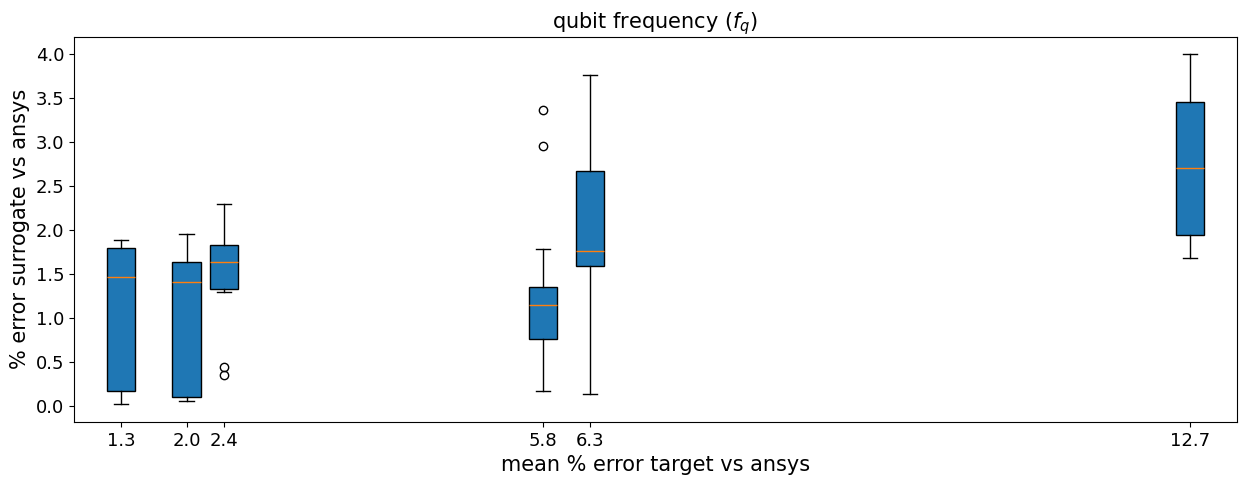

(array([-0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5]),
 [Text(0, -0.5, '−0.5'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.5, '0.5'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.5, '1.5'),
  Text(0, 2.0, '2.0'),
  Text(0, 2.5, '2.5'),
  Text(0, 3.0, '3.0'),
  Text(0, 3.5, '3.5'),
  Text(0, 4.0, '4.0'),
  Text(0, 4.5, '4.5')])

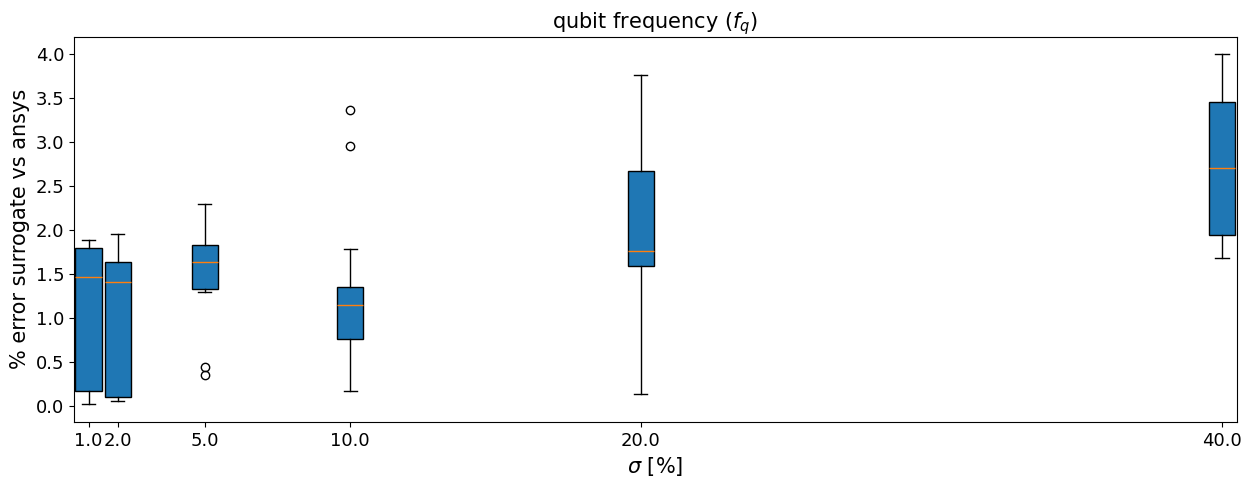

In [138]:
fig,ax = plt.subplots(figsize = (15,5))

for key in list(pred_surr_pd_frequency.keys()):
    current_pred_surr_pd_frequency = pred_surr_pd_frequency[key]
    current_pred_tar_pd_frequency = pred_tar_pd_frequency[key]

    target_mean = np.mean(current_pred_tar_pd_frequency)

    ''' plot box plots against mean percent change between EM simulator and target '''
    plt.boxplot([pred_surr_pd_frequency[key]],positions=[np.round(float(target_mean),1)],widths=.3,patch_artist=True)
    
    ''' plot box plots against gaussian sigma ''' 

    plt.ylabel(r"% error surrogate vs EM simulator",fontsize = 15)
    plt.xlabel(r"mean % error target vs EM simulator",fontsize = 15)
    plt.title("qubit frequency $(f_q)$",fontsize = 15)

plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.show()

fig,ax = plt.subplots(figsize = (15,5))
for key in list(pred_surr_pd_frequency.keys()):
    current_pred_surr_pd_frequency = pred_surr_pd_frequency[key]
    current_pred_tar_pd_frequency = pred_tar_pd_frequency[key]

    target_mean = np.mean(current_pred_tar_pd_frequency)

    ''' plot box plots against mean percent change between EM simulator and target '''
    
    ''' plot box plots against gaussian sigma ''' 
    plt.boxplot([pred_surr_pd_frequency[key]],positions=[float(key)],widths=.9,patch_artist=True)

    plt.ylabel(r"% error surrogate vs EM simulator",fontsize = 15)
    plt.xlabel(r"$\sigma$ [%]",fontsize = 15)
    plt.title("qubit frequency $(f_q)$",fontsize = 15)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)

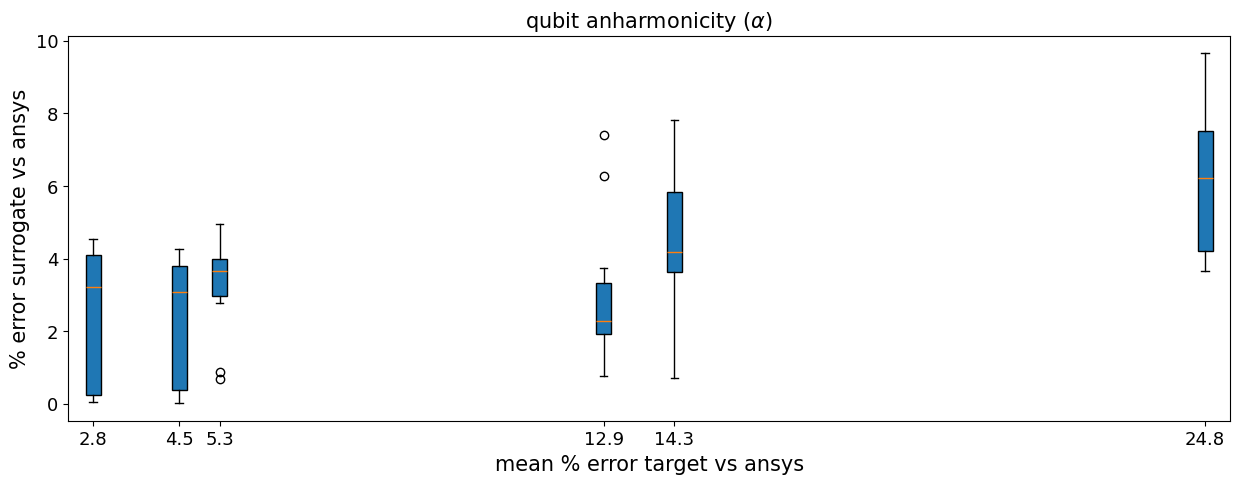

(array([-2.,  0.,  2.,  4.,  6.,  8., 10., 12.]),
 [Text(0, -2.0, '−2'),
  Text(0, 0.0, '0'),
  Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8'),
  Text(0, 10.0, '10'),
  Text(0, 12.0, '12')])

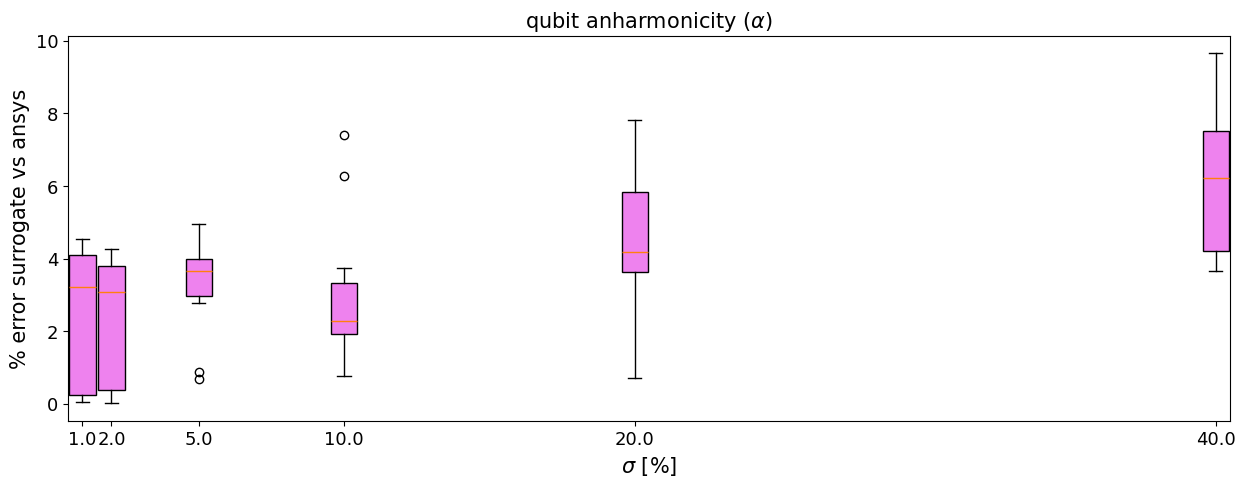

In [139]:
fig,ax = plt.subplots(figsize = (15,5))

for key in list(pred_surr_pd_frequency.keys()):
    current_pred_surr_pd_alpha = pred_surr_pd_alpha[key]
    current_pred_tar_pd_alpha = pred_tar_pd_alpha[key]

    target_mean = np.mean(current_pred_tar_pd_alpha)

    ''' plot box plots against mean percent change between EM simulator and target '''
    plt.boxplot([pred_surr_pd_alpha[key]],positions=[np.round(float(target_mean),1)],widths=.3,patch_artist=True)
    
    ''' plot box plots against gaussian sigma ''' 

    plt.ylabel(r"% error surrogate vs EM simulator",fontsize = 15)
    plt.xlabel(r"mean % error target vs EM simulator",fontsize = 15)
    plt.title(r"qubit anharmonicity $(\alpha)$",fontsize = 15)

plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.show()

fig,ax = plt.subplots(figsize = (15,5))
for key in list(pred_surr_pd_frequency.keys()):
    current_pred_surr_pd_frequency = pred_surr_pd_frequency[key]
    current_pred_tar_pd_frequency = pred_tar_pd_frequency[key]

    target_mean = np.mean(current_pred_tar_pd_frequency)

    ''' plot box plots against mean percent change between EM simulator and target '''
    
    ''' plot box plots against gaussian sigma ''' 
    bplot = plt.boxplot([pred_surr_pd_alpha[key]],positions=[float(key)],widths=.9,patch_artist=True)
    ## fill with colors
    
    for patch in bplot['boxes']:
        patch.set_facecolor("violet")

    plt.ylabel(r"% error surrogate vs EM simulator",fontsize = 15)
    plt.xlabel(r"$\sigma$ [%]",fontsize = 15)
    plt.title(r"qubit anharmonicity $(\alpha)$",fontsize = 15)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)

# Hamiltonian parameter scatter plots per $\sigma$

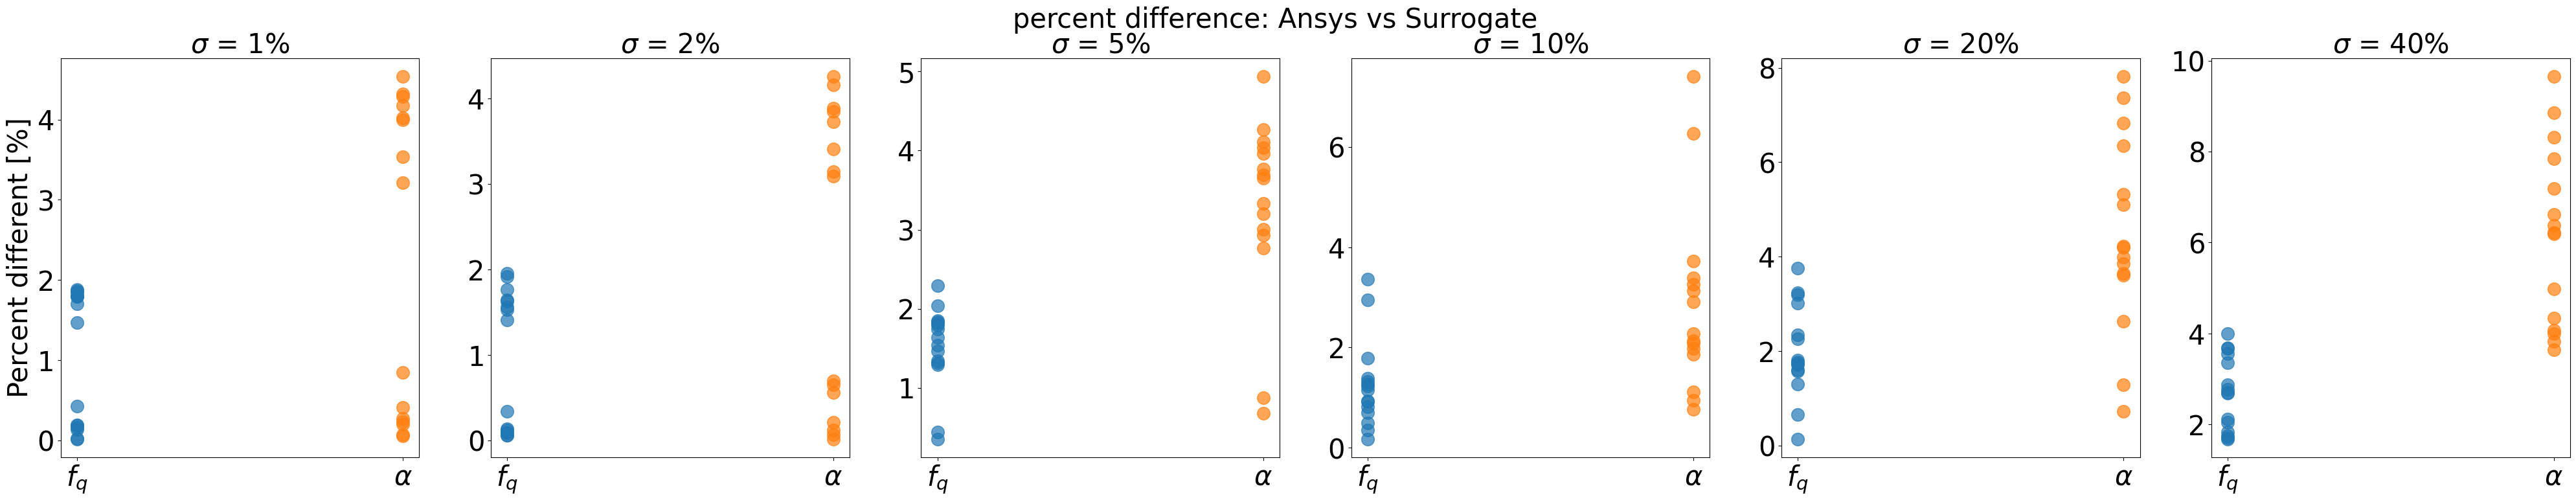

In [140]:
fig,ax = plt.subplots(1,len(pred_surr_pd_frequency),figsize = (50,8))
ax_count = 0
for key in pred_surr_pd_frequency:

    freq_y = pred_surr_pd_frequency[key]
    alpha_y = pred_surr_pd_alpha[key]

    ax[ax_count].scatter([r"$f_q$"]*len(freq_y),freq_y,color = "C0",s = 200,alpha = 0.7)
    ax[ax_count].scatter([r"$\alpha$"]*len(alpha_y),alpha_y,color = "C1",s = 200,alpha = 0.7)
    
    ax[ax_count].tick_params("y",labelsize = 30)
    ax[ax_count].tick_params("x",labelsize = 30)
    ax[ax_count].set_title(r"$\sigma$ = {}%".format(key),fontsize = 30)
    ax[0].set_ylabel("Percent different [%]",fontsize =30)

    ax_count += 1

fig.suptitle("percent difference: EM simulator vs Surrogate",fontsize = 30)
plt.savefig("Ansys_vs_surrogate.png",bbox_inches='tight')

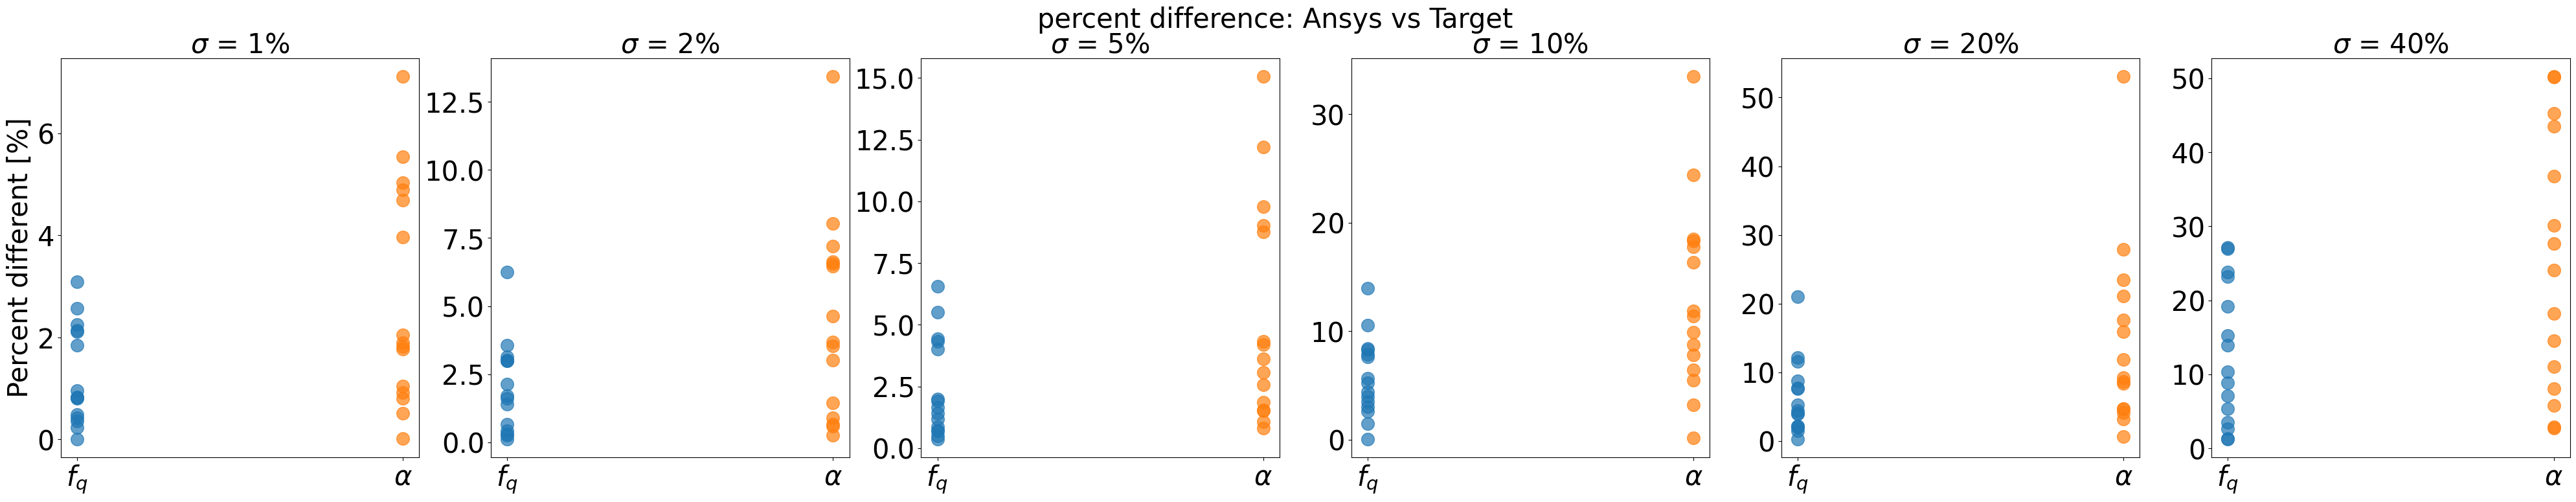

In [100]:
fig,ax = plt.subplots(1,len(pred_surr_pd_frequency),figsize = (50,8))
ax_count = 0
for key in pred_surr_pd_frequency:

    freq_y = pred_tar_pd_frequency[key]
    alpha_y = pred_tar_pd_alpha[key]

    ax[ax_count].scatter([r"$f_q$"]*len(freq_y),freq_y,color = "C0",s = 200,alpha = 0.7)
    ax[ax_count].scatter([r"$\alpha$"]*len(alpha_y),alpha_y,color = "C1",s = 200,alpha = 0.7)
    
    ax[ax_count].tick_params("y",labelsize = 30)
    ax[ax_count].tick_params("x",labelsize = 30)
    ax[ax_count].set_title(r"$\sigma$ = {}%".format(key),fontsize = 30)
    ax[0].set_ylabel("Percent different [%]",fontsize =30)

    ax_count += 1

fig.suptitle("percent difference: EM simulator vs Target",fontsize = 30)
plt.savefig("Ansys_vs_target.png",bbox_inches='tight')

In [68]:
ML_results["pd_fq_surrogate_vs_ansys"] = list(np.array(list(pred_surr_pd_frequency.values())).flatten())
ML_results["pd_alpha_surrogate_vs_ansys"] = list(np.array(list(pred_surr_pd_alpha.values())).flatten())
ML_results["pd_fq_target_vs_ansys"] = list(np.array(list(pred_tar_pd_frequency.values())).flatten())
ML_results["pd_alpha_target_vs_ansys"] = list(np.array(list(pred_tar_pd_alpha.values())).flatten())

In [69]:
ML_results.to_csv(str(Path(RESULTS_DIR) / "validation" / "MLP+Ansys_results_random_stress_test.csv"),index = False)

# Linear Sweeps

In [144]:
simulation_results = pd.read_csv(str(Path(RESULTS_DIR) / "validation" / "linear_sweep_20pct_ansys_results.csv"))
ML_results = pd.read_csv(str(REPO_ROOT / 'experiments' / 'model_predict_qubit_TransmonCross_cap_matrix' / 'results' / "validation/linear_sweep_20pct_sigma_for_em_sim.csv"))

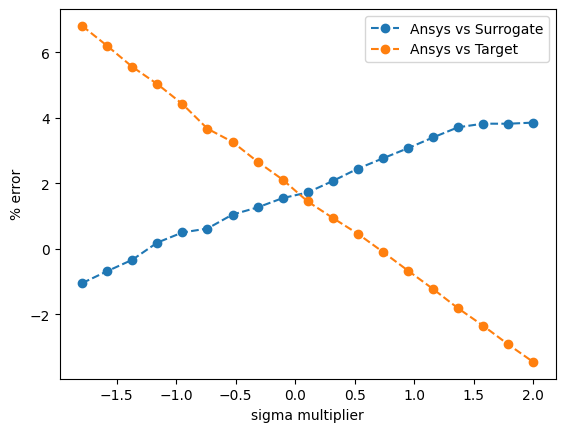

In [145]:
fig,ax = plt.subplots()
x = []
pd_pt = []
pd_ps = []
for i in range(len(simulation_results)):
    current_sim = simulation_results.iloc[i]
    current_ml = ML_results.iloc[i]
    x.append(current_ml.sigma_multiplier)

    predicted = eval(current_sim.pred_H_params)
    surrogate = eval(current_sim.surrogate_H_params)
    target = eval(current_sim.target_H_params)

    f_p = predicted["qubit_frequency_GHz"]
    f_s = surrogate["qubit_frequency_GHz"]
    f_t = target["qubit_frequency_GHz"]

    pd_pt.append(percentDiff(f_p,f_t))
    pd_ps.append(percentDiff(f_p,f_s))

ax.plot(x[1:],pd_ps[1:],marker = "o",linestyle = 'dashed',label = "EM simulator vs Surrogate")
ax.plot(x[1:],pd_pt[1:],marker = "o",linestyle = 'dashed',label = "EM simulator vs Target")
plt.xlabel("sigma multiplier")
plt.ylabel("% error")
plt.legend()
plt.show()

In [146]:
x

[-2.0,
 -1.78947,
 -1.57895,
 -1.36842,
 -1.15789,
 -0.947368,
 -0.736842,
 -0.526316,
 -0.315789,
 -0.105263,
 0.105263,
 0.315789,
 0.526316,
 0.736842,
 0.947368,
 1.15789,
 1.36842,
 1.57895,
 1.78947,
 2.0]

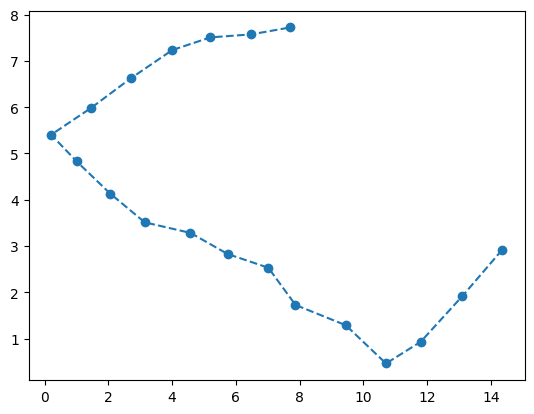

In [90]:
fig,ax = plt.subplots()
x = []
pd_pt = []
pd_ps = []
for i in range(len(simulation_results)):
    current_sim = simulation_results.iloc[i]
    current_ml = ML_results.iloc[i]
    x.append(current_ml.sigma_multiplier)

    predicted = eval(current_sim.pred_H_params)
    surrogate = eval(current_sim.surrogate_H_params)
    target = eval(current_sim.target_H_params)

    alpha_p = predicted["anharmonicity_MHz"]
    alpha_s = surrogate["anharmonicity_MHz"]
    alpha_t = target["anharmonicity_MHz"]

    pd_pt.append(percentDiff(alpha_p,alpha_t))
    pd_ps.append(percentDiff(alpha_p,alpha_s))

ax.plot(pd_pt[1:],pd_ps[1:],marker = "o",linestyle = 'dashed')

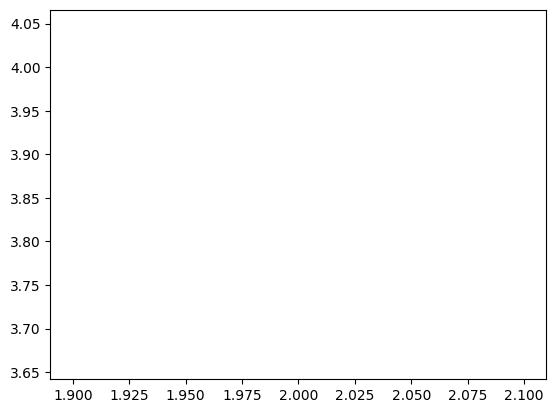

In [81]:
plt.plot(x,percentDiff(f_p,f_s))